# FastAPI latency SLA — presentation bench

Бенчмарк живого сервера `GET /extract` для техлида:

- **gold** — все запросы из `artifacts/gold/bio_liza.jsonl` (~200)
- **demo easy** — 5 простых из silver
- **demo medium** — 10 средней сложности
- **demo hard** — 10 сложных (опечатки, aliases, смешанный ввод)

Метрики: mean / median / **p90 / p95 / p99** / max, success rate.
Считаем и **server `latency_ms`** (внутри каскада), и **client RTT** (HTTP + JSON).

Сервер должен быть поднят:

```bash
uvicorn src.server.app:app --host 0.0.0.0 --port 8000
```


In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import httpx
import numpy as np
import pandas as pd

# repo root: notebook lives in src/server/ (or run from repo root)
_cwd = Path.cwd().resolve()
ROOT = None
for cand in [_cwd, _cwd.parent, _cwd.parent.parent]:
    c = cand.resolve()
    if (c / "artifacts" / "gold" / "bio_liza.jsonl").exists():
        ROOT = c
        break
if ROOT is None:
    raise FileNotFoundError("Cannot find repo root with artifacts/gold/bio_liza.jsonl")

BASE_URL = "http://127.0.0.1:8000"
GOLD_PATH = ROOT / "artifacts" / "gold" / "bio_liza.jsonl"
OUT_JSON = ROOT / "artifacts" / "metrics" / "latency_sla.json"
OUT_CSV = ROOT / "artifacts" / "metrics" / "latency_sla_rows.csv"
OUT_JSON.parent.mkdir(parents=True, exist_ok=True)

print("ROOT", ROOT)
print("GOLD", GOLD_PATH.exists(), GOLD_PATH)


ROOT D:\Projects-26-06-2026\mvideo-ner-search
GOLD True D:\Projects-26-06-2026\mvideo-ner-search\artifacts\gold\bio_liza.jsonl


In [2]:
# --- health + warmup ---
with httpx.Client(base_url=BASE_URL, timeout=30.0) as client:
    h = client.get("/health")
    h.raise_for_status()
    print("health:", h.json())
    # cold → warm (исключаем из SLA)
    for q in ["samsung", "пылесос dyson", "телефон"]:
        client.get("/extract", params={"query": q})
print("warmup done")


health: {'status': 'ok', 'crf': True, 'brand_clf': True, 'attr_clf': True, 'spellfix': True, 'category_clf': False}


warmup done


In [3]:
def percentile(xs: list[float], p: float) -> float:
    if not xs:
        return float("nan")
    return float(np.percentile(np.asarray(xs, dtype=float), p))


def summarize(lat_server: list[float], lat_client: list[float], *, n_ok: int, n_err: int) -> dict:
    def block(xs: list[float]) -> dict:
        return {
            "n": len(xs),
            "mean_ms": round(float(np.mean(xs)), 3) if xs else None,
            "std_ms": round(float(np.std(xs)), 3) if xs else None,
            "min_ms": round(float(np.min(xs)), 3) if xs else None,
            "p50_ms": round(percentile(xs, 50), 3) if xs else None,
            "p90_ms": round(percentile(xs, 90), 3) if xs else None,
            "p95_ms": round(percentile(xs, 95), 3) if xs else None,
            "p99_ms": round(percentile(xs, 99), 3) if xs else None,
            "max_ms": round(float(np.max(xs)), 3) if xs else None,
        }

    total = n_ok + n_err
    return {
        "n_total": total,
        "n_ok": n_ok,
        "n_err": n_err,
        "success_rate": round(n_ok / total, 4) if total else 0.0,
        "server_latency_ms": block(lat_server),
        "client_rtt_ms": block(lat_client),
        "sla": {
            "target_p95_server_ms": 100.0,
            "p95_server_ok": bool(lat_server) and percentile(lat_server, 95) <= 100.0,
            "target_p95_client_ms": 150.0,
            "p95_client_ok": bool(lat_client) and percentile(lat_client, 95) <= 150.0,
        },
    }


def run_bench(name: str, queries: list[str], *, repeats: int, client: httpx.Client):
    rows = []
    lat_s, lat_c = [], []
    n_ok = n_err = 0
    for rep in range(repeats):
        for q in queries:
            t0 = time.perf_counter()
            try:
                r = client.get("/extract", params={"query": q})
                rtt = (time.perf_counter() - t0) * 1000.0
                r.raise_for_status()
                body = r.json()
                srv = float(body.get("latency_ms") or 0.0)
                n_ok += 1
                lat_s.append(srv)
                lat_c.append(rtt)
                rows.append(
                    {
                        "suite": name,
                        "repeat": rep,
                        "query": q,
                        "ok": True,
                        "server_ms": srv,
                        "client_ms": round(rtt, 3),
                        "brand": body.get("brand"),
                        "category": body.get("category"),
                        "model": body.get("model"),
                        "n_entities": len(body.get("entities") or []),
                        "n_spell_fixes": len(body.get("spell_fixes") or []),
                        "error": None,
                    }
                )
            except Exception as e:
                rtt = (time.perf_counter() - t0) * 1000.0
                n_err += 1
                rows.append(
                    {
                        "suite": name,
                        "repeat": rep,
                        "query": q,
                        "ok": False,
                        "server_ms": None,
                        "client_ms": round(rtt, 3),
                        "brand": None,
                        "category": None,
                        "model": None,
                        "n_entities": None,
                        "n_spell_fixes": None,
                        "error": str(e)[:200],
                    }
                )
    summary = summarize(lat_s, lat_c, n_ok=n_ok, n_err=n_err)
    summary["suite"] = name
    return summary, pd.DataFrame(rows)


## Demo suites

- **easy** — короткие silver-запросы (точно были в слабой разметке)
- **medium** — brand + category + attr/model, без сильных опечаток
- **hard** — aliases, опечатки, смешанный ввод


In [4]:
EASY = [
    "samsung",
    "пылесос",
    "геймпад xbox",
    "nintendo switch 2",
    "телевизоры haier 50",
]

MEDIUM = [
    "телевизор samsung 55 дюймов",
    "ноутбук asus 16 гб",
    "смартфон xiaomi 128gb",
    "пылесос dyson v15",
    "холодильник indesit no frost",
    "наушники jbl tune 510",
    "стиральная машина bosch 8 кг",
    "монитор lg 27",
    "планшет samsung tab s9",
    "чайник redmond",
]

HARD = [
    "телфон 16 гь",
    "сони плейстейшен 5",
    "ноутбок asus 16гь",
    "планше тxiaomi",
    "айфон 16 про макс",
    "лэптоп ксяоми редми",
    "playstation5 sony slim",
    "тв самсунг 65 4k",
    "морозилка индесит 200л",
    "х0лодильник bosch",
]

gold_queries = []
for line in GOLD_PATH.read_text(encoding="utf-8").splitlines():
    if not line.strip():
        continue
    gold_queries.append(json.loads(line)["query"])

print(f"gold={len(gold_queries)} easy={len(EASY)} medium={len(MEDIUM)} hard={len(HARD)}")


gold=200 easy=5 medium=10 hard=10


## Прогон

In [5]:
summaries = []
all_rows = []

with httpx.Client(base_url=BASE_URL, timeout=30.0) as client:
    # demo: 3 repeats для устойчивых перцентилей на малых N
    for name, qs, reps in [
        ("demo_easy", EASY, 3),
        ("demo_medium", MEDIUM, 3),
        ("demo_hard", HARD, 3),
        ("gold", gold_queries, 1),
    ]:
        print(f"\n=== {name} (n={len(qs)} x{reps}) ===")
        s, df = run_bench(name, qs, repeats=reps, client=client)
        summaries.append(s)
        all_rows.append(df)
        srv = s["server_latency_ms"]
        print(
            f"ok={s['n_ok']}/{s['n_total']}  "
            f"server p50={srv['p50_ms']} p90={srv['p90_ms']} p95={srv['p95_ms']} "
            f"p99={srv['p99_ms']} max={srv['max_ms']}  "
            f"SLA p95<=100: {s['sla']['p95_server_ok']}"
        )

rows_df = pd.concat(all_rows, ignore_index=True)
sum_df = pd.json_normalize(summaries)
display_cols = [
    "suite",
    "n_ok",
    "n_err",
    "success_rate",
    "server_latency_ms.mean_ms",
    "server_latency_ms.p50_ms",
    "server_latency_ms.p90_ms",
    "server_latency_ms.p95_ms",
    "server_latency_ms.p99_ms",
    "server_latency_ms.max_ms",
    "client_rtt_ms.p95_ms",
    "sla.p95_server_ok",
]
sum_df[display_cols]



=== demo_easy (n=5 x3) ===


ok=15/15  server p50=8.454 p90=27.569 p95=29.225 p99=31.674 max=32.286  SLA p95<=100: True

=== demo_medium (n=10 x3) ===


ok=30/30  server p50=14.82 p90=39.885 p95=44.091 p99=45.745 max=46.207  SLA p95<=100: True

=== demo_hard (n=10 x3) ===


ok=30/30  server p50=36.312 p90=54.749 p95=55.215 p99=56.088 max=56.383  SLA p95<=100: True

=== gold (n=200 x1) ===


ok=200/200  server p50=35.543 p90=83.515 p95=93.643 p99=109.779 max=166.976  SLA p95<=100: True


,suite,n_ok,n_err,success_rate,server_latency_ms.mean_ms,server_latency_ms.p50_ms,server_latency_ms.p90_ms,server_latency_ms.p95_ms,server_latency_ms.p99_ms,server_latency_ms.max_ms,client_rtt_ms.p95_ms,sla.p95_server_ok
0,demo_easy,15,0,1.0,11.523,8.454,27.569,29.225,31.674,32.286,31.444,True
1,demo_medium,30,0,1.0,18.816,14.820,39.885,44.091,45.745,46.207,46.318,True
2,demo_hard,30,0,1.0,34.636,36.312,54.749,55.215,56.088,56.383,57.574,True
3,gold,200,0,1.0,39.041,35.543,83.515,93.643,109.779,166.976,96.164,True


In [6]:
# детализация demo: факты по одному прогону (repeat=0)
demo = rows_df[(rows_df["suite"].str.startswith("demo_")) & (rows_df["repeat"] == 0)].copy()
demo[["suite", "query", "server_ms", "brand", "category", "model", "n_entities", "n_spell_fixes"]]


,suite,query,server_ms,brand,category,model,n_entities,n_spell_fixes
0,demo_easy,samsung,2.702,Samsung,NaN,NaN,1,0
1,demo_easy,пылесос,12.416,NaN,пылесос,NaN,1,0
2,demo_easy,геймпад xbox,4.822,Xbox,геймпад,NaN,2,0
3,demo_easy,nintendo switch 2,27.052,Nintendo,NaN,switch 2,2,0
4,demo_easy,телевизоры haier 50,7.877,Haier,телевизоры,NaN,2,0
15,demo_medium,телевизор samsung 55 дюймов,39.106,Samsung,телевизоры,NaN,3,0
16,demo_medium,ноутбук asus 16 гб,15.775,ASUS,ноутбуки,NaN,3,0
17,demo_medium,смартфон xiaomi 128gb,9.985,Xiaomi,смартфон,128 gb,3,1
18,demo_medium,пылесос dyson v15,6.988,Dyson,пылесос,v15,3,0
19,demo_medium,холодильник indesit no frost,24.230,Indesit,холодильники,NaN,2,0


In [7]:
# сохранение артефактов для презентации
payload = {
    "base_url": BASE_URL,
    "gold_path": str(GOLD_PATH.as_posix()),
    "suites": summaries,
    "demo_queries": {"easy": EASY, "medium": MEDIUM, "hard": HARD},
    "notes": (
        "server_latency_ms = extractor cascade (SpellFix→rules→CRF→clf); "
        "client_rtt_ms = HTTP round-trip. Warmup excluded. "
        "Demo suites repeated 3x for stable percentiles."
    ),
}
OUT_JSON.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
rows_df.to_csv(OUT_CSV, index=False)
print("wrote", OUT_JSON)
print("wrote", OUT_CSV)


wrote D:\Projects-26-06-2026\mvideo-ner-search\artifacts\metrics\latency_sla.json
wrote D:\Projects-26-06-2026\mvideo-ner-search\artifacts\metrics\latency_sla_rows.csv


## SLA snapshot (техлид)

Цели для MVP-демо (ориентир каскада, не прод-SLO):

- **server p95 ≤ 100 ms**
- **client p95 ≤ 150 ms** (localhost)
- **success rate = 100%**


In [8]:
sla_tbl = []
for s in summaries:
    sla_tbl.append(
        {
            "suite": s["suite"],
            "n": s["n_ok"],
            "success": s["success_rate"],
            "p50_server": s["server_latency_ms"]["p50_ms"],
            "p90_server": s["server_latency_ms"]["p90_ms"],
            "p95_server": s["server_latency_ms"]["p95_ms"],
            "p99_server": s["server_latency_ms"]["p99_ms"],
            "max_server": s["server_latency_ms"]["max_ms"],
            "p95_client": s["client_rtt_ms"]["p95_ms"],
            "pass_p95_server": s["sla"]["p95_server_ok"],
            "pass_p95_client": s["sla"]["p95_client_ok"],
        }
    )
pd.DataFrame(sla_tbl)


,suite,n,success,p50_server,p90_server,p95_server,p99_server,max_server,p95_client,pass_p95_server,pass_p95_client
0,demo_easy,15,1.0,8.454,27.569,29.225,31.674,32.286,31.444,True,True
1,demo_medium,30,1.0,14.820,39.885,44.091,45.745,46.207,46.318,True,True
2,demo_hard,30,1.0,36.312,54.749,55.215,56.088,56.383,57.574,True,True
3,gold,200,1.0,35.543,83.515,93.643,109.779,166.976,96.164,True,True


wrote D:\Projects-26-06-2026\mvideo-ner-search\artifacts\metrics\latency_sla_cdf.png


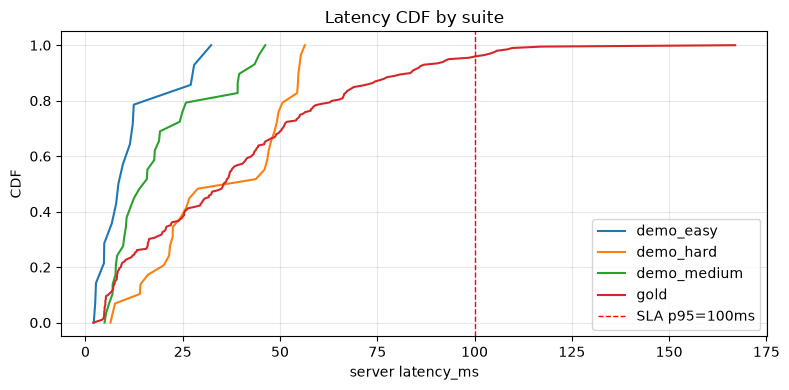

In [9]:
# CDF plot
try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(8, 4))
    for suite, g in rows_df[rows_df["ok"]].groupby("suite"):
        xs = sorted(g["server_ms"].tolist())
        ys = np.linspace(0, 1, len(xs), endpoint=True)
        ax.plot(xs, ys, label=suite)
    ax.axvline(100, color="red", ls="--", lw=1, label="SLA p95=100ms")
    ax.set_xlabel("server latency_ms")
    ax.set_ylabel("CDF")
    ax.set_title("Latency CDF by suite")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig_path = ROOT / "artifacts" / "metrics" / "latency_sla_cdf.png"
    fig.savefig(fig_path, dpi=120)
    print("wrote", fig_path)
    plt.show()
except Exception as e:
    print("plot skipped:", e)
